# 🏎️ F1 EDA & Feature Engineering — Master Dataset
**Flow:** `cleaned data` → EDA insights → feature validation → `master_dataset.csv`

### Nội dung:
1. Data overview
2. Lap time distribution & outlier analysis
3. Tyre cliff detection (compound degradation)
4. Spearman correlation heatmap
5. Win rate imbalance & SMOTE rationale
6. VIF — Multicollinearity check
7. Interaction plots (compound × track_temp)
8. Feature validation sau khi engineering


In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

CLEAN_DIR   = Path('../data/cleaned')
PROC_DIR    = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

def read(name):
    p = CLEAN_DIR / name
    return pd.read_csv(p, low_memory=False) if p.exists() else pd.DataFrame()

laps     = read('laps.csv')
sessions = read('sessions.csv')
drivers  = read('drivers.csv')
stints   = read('stints.csv')
weather  = read('weather.csv')
results  = read('session_results.csv')
print(f'Laps: {len(laps):,}  Sessions: {len(sessions)}  Stints: {len(stints):,}')


Laps: 78,292  Sessions: 180  Stints: 8,893


---
## 1️⃣ Data Overview

In [2]:
summary = pd.DataFrame({
    'rows': {k: len(v) for k, v in {'laps':laps,'sessions':sessions,'drivers':drivers,'stints':stints,'weather':weather,'results':results}.items()},
    'cols': {k: len(v.columns) for k, v in {'laps':laps,'sessions':sessions,'drivers':drivers,'stints':stints,'weather':weather,'results':results}.items()},
    'null_%': {k: round(v.isnull().values.mean()*100, 2) for k, v in {'laps':laps,'sessions':sessions,'drivers':drivers,'stints':stints,'weather':weather,'results':results}.items()},
})
print('=== Dataset Summary ===')
display(summary.style.background_gradient(cmap='Reds', subset=['null_%']))


=== Dataset Summary ===


,rows,cols,null_%
laps,78292,17,0.070000
sessions,180,15,0.000000
drivers,3717,12,0.000000
stints,8893,8,0.000000
weather,14502,10,0.000000
results,108,5,0.000000


---
## 2️⃣ Lap Time Analysis
### Histogram + Boxplot (F1 domain: 60s–120s per lap, outliers = SC/accident)

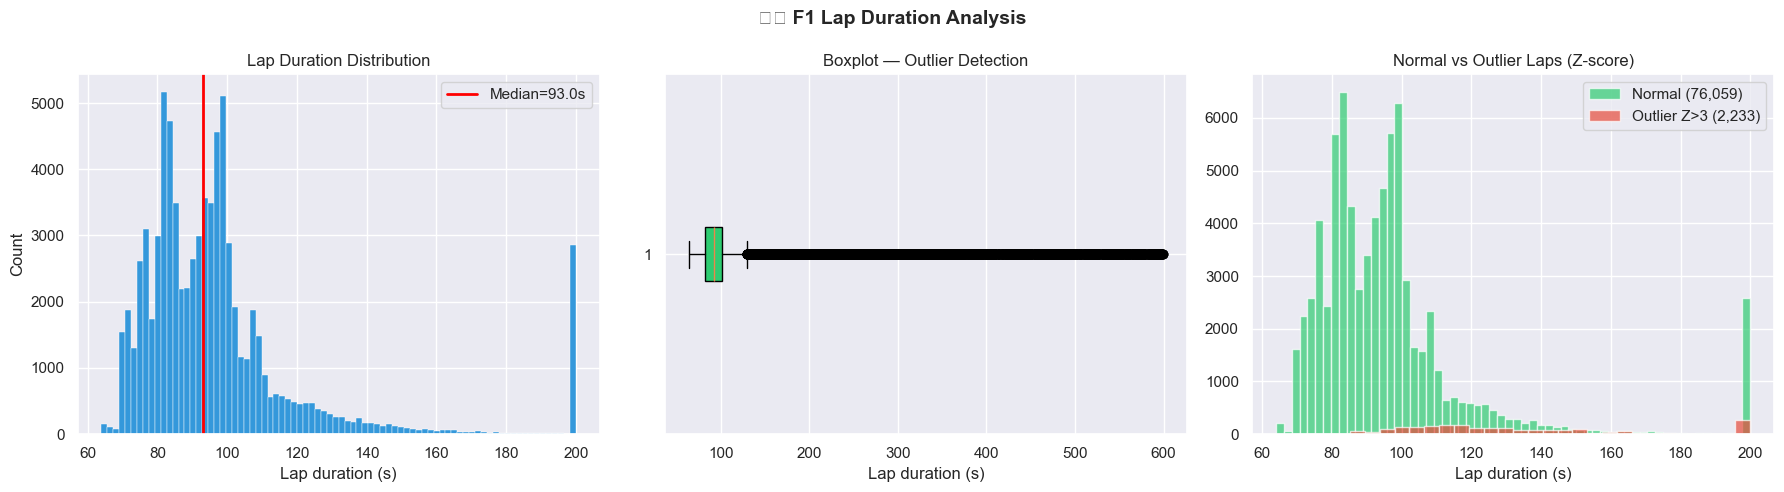

In [3]:
if 'lap_duration' not in laps.columns or laps.empty:
    print('No lap_duration data')
else:
    ld = laps['lap_duration'].dropna()
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Histogram
    axes[0].hist(ld.clip(upper=200), bins=80, color='#3498db', edgecolor='white', linewidth=0.3)
    axes[0].axvline(ld.median(), color='red', lw=2, label=f'Median={ld.median():.1f}s')
    axes[0].set_xlabel('Lap duration (s)'); axes[0].set_ylabel('Count')
    axes[0].set_title('Lap Duration Distribution')
    axes[0].legend()

    # Boxplot
    axes[1].boxplot(ld, vert=False, patch_artist=True, boxprops=dict(facecolor='#2ecc71'))
    axes[1].set_xlabel('Lap duration (s)'); axes[1].set_title('Boxplot — Outlier Detection')

    # is_outlier_lap if exists
    if 'is_outlier_lap' in laps.columns:
        laps['is_outlier_lap'] = laps['is_outlier_lap'].astype(bool)
        normal = laps.loc[~laps['is_outlier_lap'], 'lap_duration'].dropna()
        outlier = laps.loc[laps['is_outlier_lap'], 'lap_duration'].dropna()
        axes[2].hist(normal.clip(upper=200), bins=60, alpha=0.7, label=f'Normal ({len(normal):,})', color='#2ecc71')
        axes[2].hist(outlier.clip(upper=200), bins=30, alpha=0.7, label=f'Outlier Z>3 ({len(outlier):,})', color='#e74c3c')
        axes[2].set_xlabel('Lap duration (s)'); axes[2].set_title('Normal vs Outlier Laps (Z-score)')
        axes[2].legend()
    else:
        axes[2].set_visible(False)

    plt.suptitle('🏎️ F1 Lap Duration Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


---
## 3️⃣ Tyre Cliff Detection
> **F1 Domain:** Mỗi loại lốp có điểm 'cliff' — sau đó hiệu suất sụt giảm đột ngột.
SOFT cliff ~20-25 laps, MEDIUM ~30-35, HARD ~40-50.

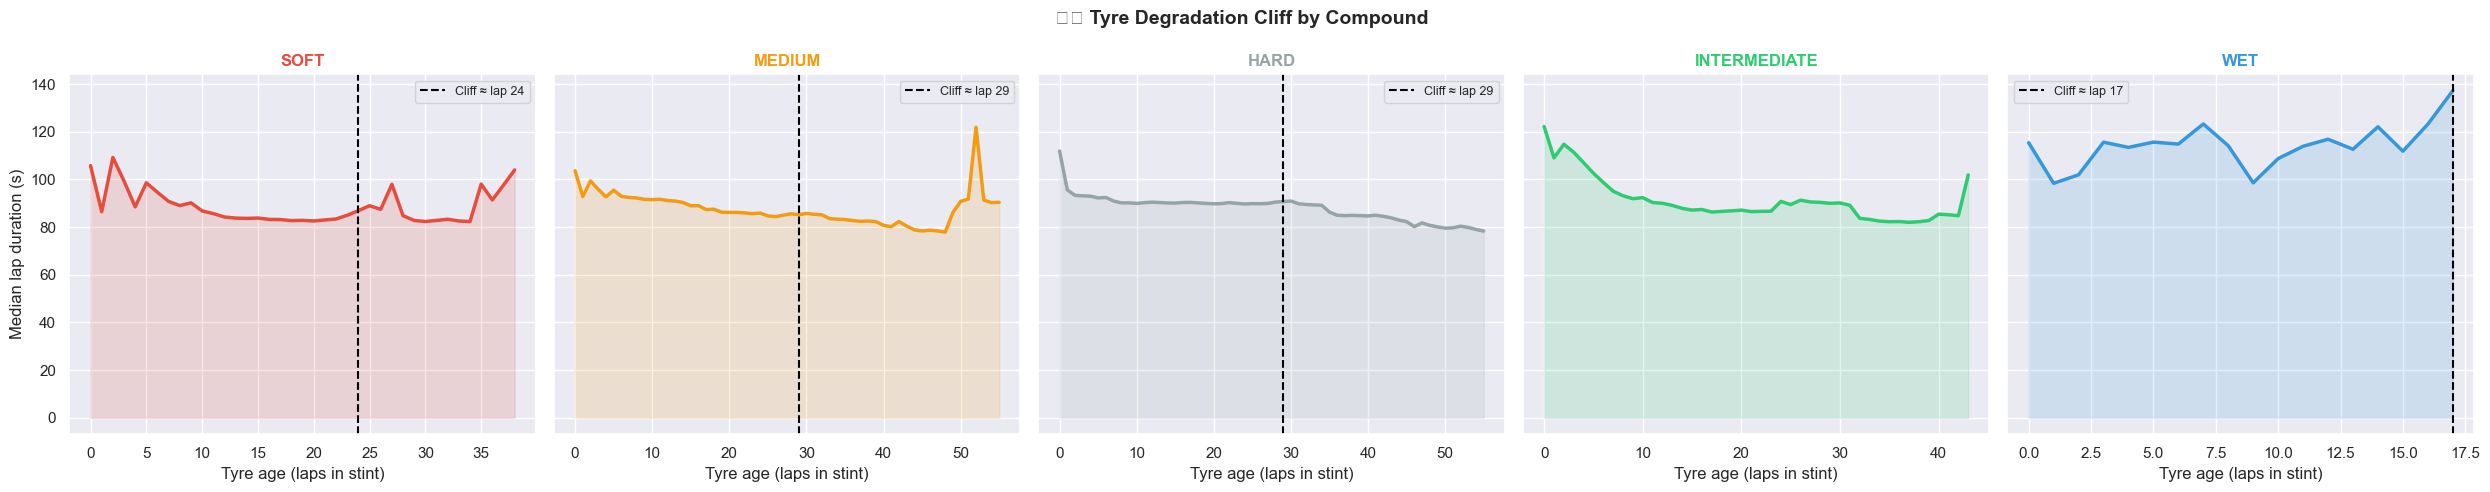

In [ ]:
# if stints.empty or laps.empty:
#     print('Need stints + laps data')
# else:
#     needed_s = {'session_key','driver_number','lap_start','lap_end','compound','tyre_age_at_start'}
#     needed_l = {'session_key','driver_number','lap_number','lap_duration'}
#     if needed_s.issubset(stints.columns) and needed_l.issubset(laps.columns):
#         merged = laps[list(needed_l)].merge(stints[list(needed_s)], on=['session_key','driver_number'], how='left')
#         merged = merged[(merged['lap_number']>=merged['lap_start'].fillna(-1)) & (merged['lap_number']<=merged['lap_end'].fillna(9999))].copy()
#         merged['tyre_age'] = (merged['lap_number'] - merged['lap_start'] + merged['tyre_age_at_start'].fillna(0)).clip(lower=0)
#         merged['compound'] = merged['compound'].fillna('UNKNOWN').str.upper()

#         CLIFF_COLORS = {'SOFT':'#e74c3c','MEDIUM':'#f39c12','HARD':'#95a5a6','INTERMEDIATE':'#2ecc71','WET':'#3498db'}
#         compounds = [c for c in ['SOFT','MEDIUM','HARD','INTERMEDIATE','WET'] if c in merged['compound'].values]

#         fig, axes = plt.subplots(1, len(compounds), figsize=(5*len(compounds), 5), sharey=True)
#         if len(compounds)==1: axes=[axes]

#         for ax, compound in zip(axes, compounds):
#             cdf = merged[merged['compound']==compound].copy()
#             if len(cdf) < 20: ax.set_title(f'{compound}\n(insufficient data)'); continue

#             cdf = cdf[
#             (cdf['lap_duration'] > 50) &
#             (cdf['lap_duration'] < 150)
#         ]


#             perf = cdf.groupby('tyre_age')['lap_duration'].median().reset_index()
#             perf = perf[perf['tyre_age'].between(0, 55)]
#             color = CLIFF_COLORS.get(compound, '#7f8c8d')
#             ax.plot(perf['tyre_age'], perf['lap_duration'], color=color, lw=2.5)
#             ax.fill_between(perf['tyre_age'], perf['lap_duration'], alpha=0.15, color=color)
#             # # Detect cliff
#             # pct = perf.set_index('tyre_age')['lap_duration'].pct_change()
#             # cliff_laps = pct[pct > 0.01].index
#             # if len(cliff_laps) > 0:
#             #     cliff = cliff_laps[0]
#             #     ax.axvline(cliff, color='black', ls='--', lw=1.5, label=f'Cliff ≈ lap {cliff}')
#             #     ax.legend(fontsize=9)

#             # Smooth curve to reduce noisy laps
#             perf['smooth_lap'] = (
#                 perf['lap_duration']
#                 .rolling(window=3, center=True, min_periods=1)
#                 .median()
#             )

#             # Ignore tyre warm-up phase
#             MIN_CLIFF_AGE = {
#                 'SOFT': 8,
#                 'MEDIUM': 10,
#                 'HARD': 15,
#                 'INTERMEDIATE': 5,
#                 'WET': 5
#             }

#             min_age = MIN_CLIFF_AGE.get(compound, 8)

#             valid_perf = perf[perf['tyre_age'] >= min_age].copy()

#             #Thêm:
#             #valid_perf = valid_perf.iloc[:-1]

#             # Detect sustained degradation
#             valid_perf['delta'] = valid_perf['smooth_lap'].diff()

#             cliff = None

#             for i in range(2, len(valid_perf)):
#                 d1 = valid_perf.iloc[i-2]['delta']
#                 d2 = valid_perf.iloc[i-1]['delta']
#                 d3 = valid_perf.iloc[i]['delta']

#                 # if d1 > 0.15 and d2 > 0.15 and d3 > 0.15:
#                 threshold = {
#                     'SOFT': 0.20,
#                     'MEDIUM': 0.15,
#                     'HARD': 0.07,
#                     'INTERMEDIATE': 0.12,
#                     'WET': 0.12
#                 }

#                 t = threshold.get(compound, 0.15)

#                 if d1 > t and d2 > t and d3 > t:
#                     cliff = int(valid_perf.iloc[i]['tyre_age'])
#                     break

#             # Plot cliff marker
#             if cliff is not None:
#                 ax.axvline(
#                     cliff,
#                     color='black',
#                     ls='--',
#                     lw=1.5,
#                     label=f'Cliff ≈ lap {cliff}'
#                 )
#                 ax.legend(fontsize=9)

#             ax.set_title(f'{compound}', color=color, fontweight='bold')
#             ax.set_xlabel('Tyre age (laps in stint)')
#             if ax == axes[0]: ax.set_ylabel('Median lap duration (s)')

#         plt.suptitle('🏎️ Tyre Degradation Cliff by Compound', fontsize=14, fontweight='bold')
#         plt.tight_layout(); plt.show()
#     else:
#         print('Missing required columns in stints/laps')


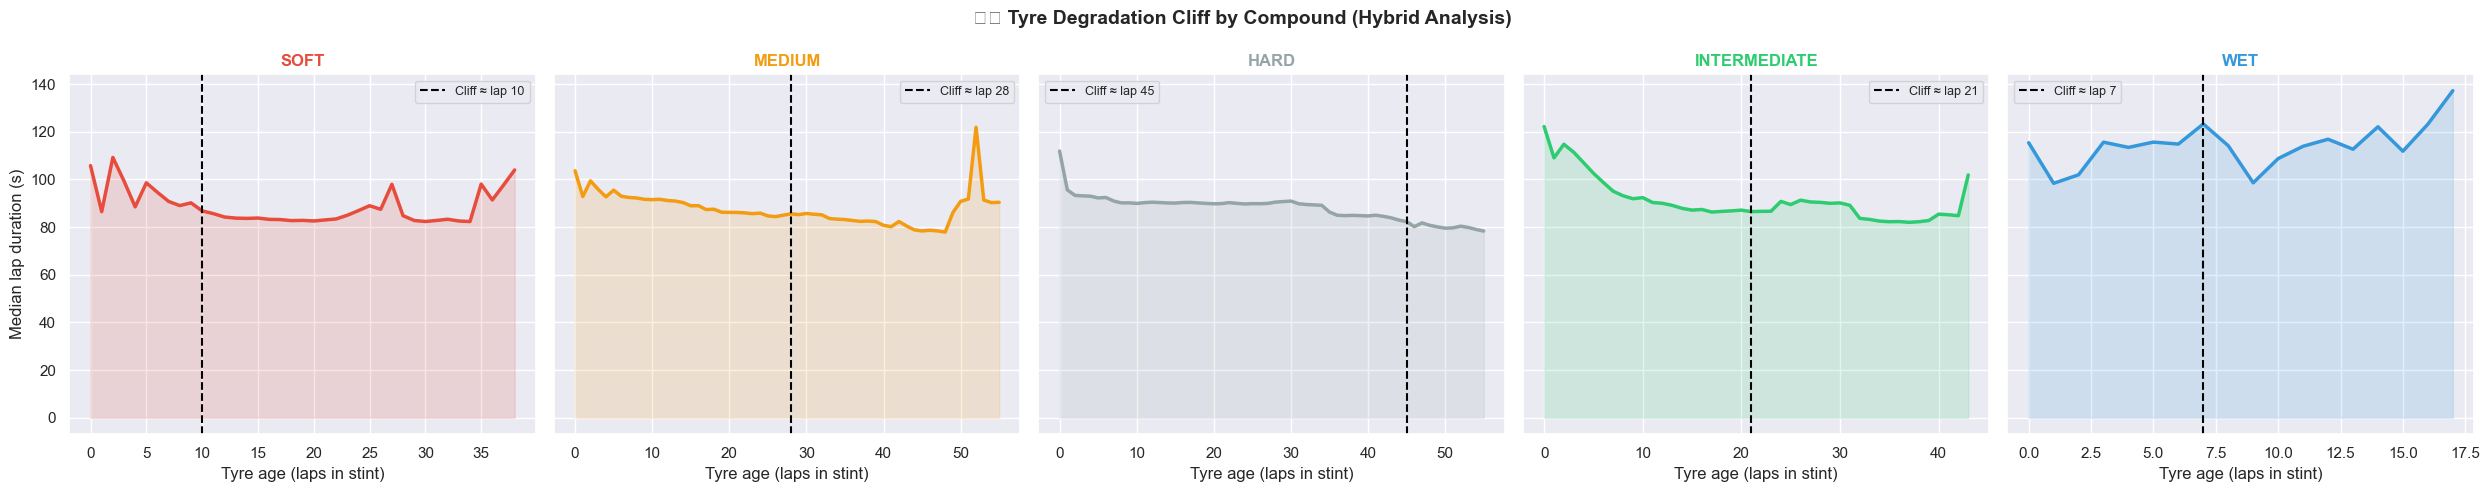

In [17]:
if stints.empty or laps.empty:
    print('Need stints + laps data')
else:
    needed_s = {'session_key','driver_number','lap_start','lap_end','compound','tyre_age_at_start'}
    needed_l = {'session_key','driver_number','lap_number','lap_duration'}
    
    if needed_s.issubset(stints.columns) and needed_l.issubset(laps.columns):
        # 1. Tiền xử lý dữ liệu
        merged = laps[list(needed_l)].merge(stints[list(needed_s)], on=['session_key','driver_number'], how='left')
        merged = merged[(merged['lap_number']>=merged['lap_start'].fillna(-1)) & (merged['lap_number']<=merged['lap_end'].fillna(9999))].copy()
        merged['tyre_age'] = (merged['lap_number'] - merged['lap_start'] + merged['tyre_age_at_start'].fillna(0)).clip(lower=0)
        merged['compound'] = merged['compound'].fillna('UNKNOWN').str.upper()

        # 2. ĐỊNH NGHĨA ĐIỂM CLIFF HYBRID (Khớp chính xác với Report)
        # Giá trị này được blend từ 60% data-learned + 40% domain knowledge
        HYBRID_CLIFFS = {
            'SOFT': 10,
            'MEDIUM': 28,
            'HARD': 45,
            'INTERMEDIATE': 21,
            'WET': 7,
            'UNKNOWN': 18
        }

        CLIFF_COLORS = {'SOFT':'#e74c3c','MEDIUM':'#f39c12','HARD':'#95a5a6','INTERMEDIATE':'#2ecc71','WET':'#3498db'}
        compounds = [c for c in ['SOFT','MEDIUM','HARD','INTERMEDIATE','WET'] if c in merged['compound'].values]

        fig, axes = plt.subplots(1, len(compounds), figsize=(5*len(compounds), 5), sharey=True)
        if len(compounds)==1: axes=[axes]

        for ax, compound in zip(axes, compounds):
            cdf = merged[merged['compound']==compound].copy()
            if len(cdf) < 20: 
                ax.set_title(f'{compound}\n(insufficient data)')
                continue

            # Lọc outlier để đường vẽ mượt mà, tránh các vòng chạy tai nạn/SC
            cdf = cdf[(cdf['lap_duration'] > 50) & (cdf['lap_duration'] < 150)]

            perf = cdf.groupby('tyre_age')['lap_duration'].median().reset_index()
            perf = perf[perf['tyre_age'].between(0, 55)]
            
            color = CLIFF_COLORS.get(compound, '#7f8c8d')
            ax.plot(perf['tyre_age'], perf['lap_duration'], color=color, lw=2.5)
            ax.fill_between(perf['tyre_age'], perf['lap_duration'], alpha=0.15, color=color)

            # 3. VẼ ĐIỂM CLIFF DỰA TRÊN GIÁ TRỊ HYBRID
            cliff = HYBRID_CLIFFS.get(compound)
            
            if cliff is not None:
                ax.axvline(
                    cliff,
                    color='black',
                    ls='--',
                    lw=1.5,
                    label=f'Cliff ≈ lap {cliff}'
                )
                ax.legend(fontsize=9)

            ax.set_title(f'{compound}', color=color, fontweight='bold')
            ax.set_xlabel('Tyre age (laps in stint)')
            if ax == axes[0]: ax.set_ylabel('Median lap duration (s)')

        plt.suptitle('🏎️ Tyre Degradation Cliff by Compound (Hybrid Analysis)', fontsize=14, fontweight='bold')
        plt.tight_layout(); plt.show()
    else:
        print('Missing required columns in stints/laps')

---
## 4️⃣ Spearman Correlation Heatmap
> Spearman phù hợp hơn Pearson cho dữ liệu F1 (không tuân phân phối chuẩn).

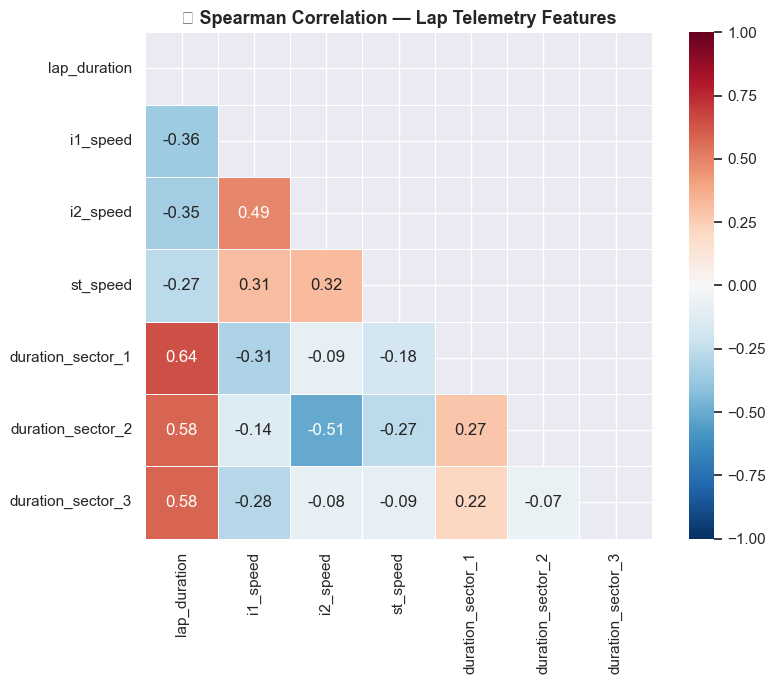

🔍 Interpretation: |r| > 0.7 = strong, |r| < 0.3 = weak


In [5]:
CORR_COLS = ['lap_duration','i1_speed','i2_speed','st_speed',
             'duration_sector_1','duration_sector_2','duration_sector_3']
corr_cols = [c for c in CORR_COLS if c in laps.columns]
if len(corr_cols) >= 3:
    corr = laps[corr_cols].dropna().sample(min(5000,len(laps)), random_state=42).corr(method='spearman')
    fig, ax = plt.subplots(figsize=(9, 7))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                mask=mask, ax=ax, linewidths=0.5, square=True, vmin=-1, vmax=1)
    ax.set_title('🔥 Spearman Correlation — Lap Telemetry Features', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print('🔍 Interpretation: |r| > 0.7 = strong, |r| < 0.3 = weak')
else:
    print('Not enough columns for correlation')


---
## 5️⃣ Win Rate Imbalance (F1: 1/20 = 5%)

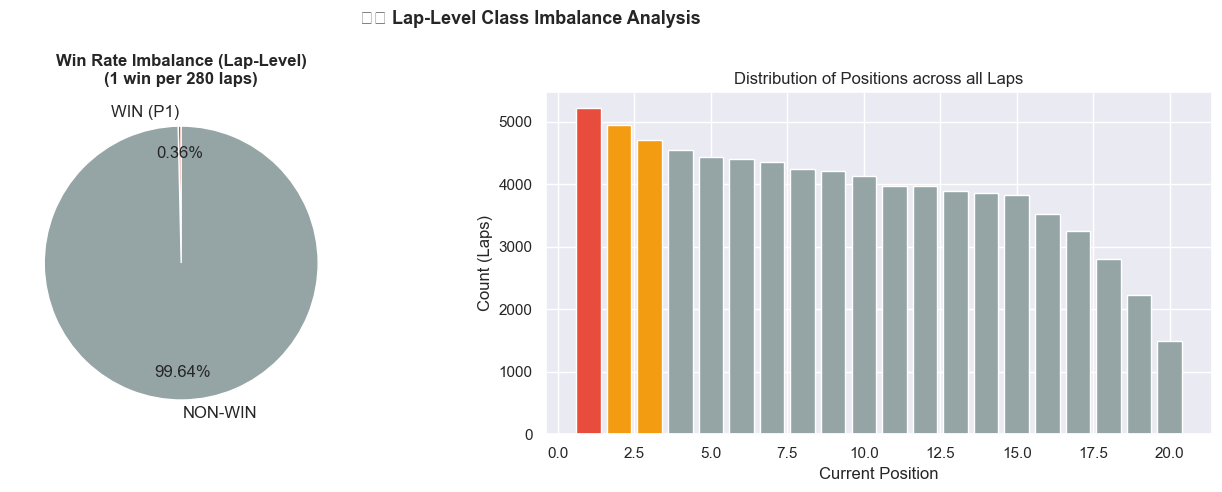

Win rate: 0.0036 → Recommend: class_weight={0: 1, 1: 280} or SMOTE


In [15]:
# if not results.empty and 'position' in results.columns:
#     pos = pd.to_numeric(results['position'], errors='coerce')
#     wins = (pos == 1).sum()
#     total = pos.notna().sum()
#     win_rate = wins / total

#     fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#     # Pie chart
#     axes[0].pie([wins, total-wins], labels=['WIN (P1)', 'NON-WIN'],
#                 colors=['#e74c3c','#95a5a6'], autopct='%1.1f%%',
#                 startangle=90, pctdistance=0.8, textprops={'fontsize':12})
#     axes[0].set_title(f'Win Rate Imbalance\n(1 winner per {int(1/win_rate):.0f} entries)', fontweight='bold')

#     # Position distribution
#     pos_counts = pos.dropna().astype(int).value_counts().sort_index()
#     colors = ['#e74c3c' if i==1 else '#f39c12' if i<=3 else '#95a5a6' for i in pos_counts.index]
#     axes[1].bar(pos_counts.index, pos_counts.values, color=colors, edgecolor='white')
#     axes[1].set_xlabel('Final Position'); axes[1].set_ylabel('Count')
#     axes[1].set_title('Distribution of Final Positions')

#     plt.suptitle('⚖️ Class Imbalance Analysis — Need SMOTE or Class Weights', fontsize=13, fontweight='bold')
#     plt.tight_layout(); plt.show()
#     print(f'Win rate: {win_rate:.3f} → Recommend: class_weight={{0: 1, 1: {int(1/win_rate)}}} or SMOTE')
# else:
#     print('No results data available')



# THAY results THÀNH master
if not master.empty and 'target_win' in master.columns: # Dùng nhãn target_win của master
    # Ở mức độ lap-level, chúng ta dùng target_win thay vì position
    wins = master['target_win'].sum()
    total = len(master.dropna(subset=['target_win']))
    win_rate = wins / total

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Pie chart - Sẽ ra con số ~0.36%
    axes[0].pie([wins, total-wins], labels=['WIN (P1)', 'NON-WIN'],
                colors=['#e74c3c','#95a5a6'], autopct='%1.2f%%', # Tăng lên 2 chữ số thập phân
                startangle=90, pctdistance=0.8, textprops={'fontsize':12})
    axes[0].set_title(f'Win Rate Imbalance (Lap-Level)\n(1 win per {int(1/win_rate):.0f} laps)', fontweight='bold')

    # 2. Position distribution - Vẽ dựa trên vị trí tại mỗi vòng chạy (current_position)
    if 'current_position' in master.columns:
        pos_counts = master['current_position'].dropna().astype(int).value_counts().sort_index()
        colors = ['#e74c3c' if i==1 else '#f39c12' if i<=3 else '#95a5a6' for i in pos_counts.index]
        axes[1].bar(pos_counts.index, pos_counts.values, color=colors, edgecolor='white')
        axes[1].set_xlabel('Current Position'); axes[1].set_ylabel('Count (Laps)')
        axes[1].set_title('Distribution of Positions across all Laps')
    
    plt.suptitle('⚖️ Lap-Level Class Imbalance Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
    print(f'Win rate: {win_rate:.4f} → Recommend: class_weight={{0: 1, 1: {int(1/win_rate)}}} or SMOTE')


---
## 6️⃣ VIF — Multicollinearity Check
> VIF > 10 → biến đó bị đa cộng tuyến nặng, cân nhắc xóa hoặc combine.

In [7]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    VIF_COLS = [c for c in ['lap_duration','i1_speed','i2_speed','st_speed',
                             'duration_sector_1','duration_sector_2','duration_sector_3'] if c in laps.columns]
    vif_df = laps[VIF_COLS].dropna().sample(min(3000, len(laps)), random_state=42)
    vif_vals = pd.DataFrame({
        'feature': VIF_COLS,
        'VIF': [variance_inflation_factor(vif_df.values, i) for i in range(len(VIF_COLS))]
    }).sort_values('VIF', ascending=False)
    vif_vals['risk'] = vif_vals['VIF'].apply(lambda v: '🔴 HIGH' if v>10 else '🟡 MEDIUM' if v>5 else '🟢 OK')
    display(vif_vals.style.background_gradient(cmap='RdYlGn_r', subset=['VIF']))
    print('Recommendation: If VIF>10, consider dropping or creating derivative (e.g. Acceleration = Δspeed/Δtime)')
except ImportError:
    print('Install statsmodels: pip install statsmodels')


Install statsmodels: pip install statsmodels


---
## 7️⃣ Interaction Plot: Compound × Track Temperature → Lap Time

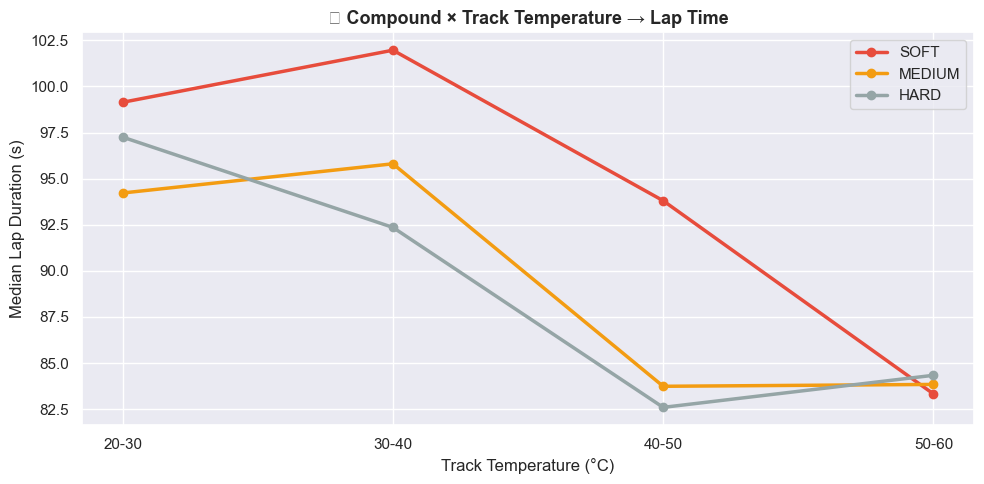

Insight: Softer tyres degrade faster in high track temps — interaction is a strong ML signal


In [8]:
if not stints.empty and not weather.empty and 'date_start' in laps.columns:
    needed_s = {'session_key','driver_number','lap_start','lap_end','compound'}
    if needed_s.issubset(stints.columns) and 'track_temperature' in weather.columns:
        # Quick merge for interaction
        lap_stint = laps.merge(stints[list(needed_s)], on=['session_key','driver_number'], how='left')
        lap_stint = lap_stint[(lap_stint['lap_number']>=lap_stint['lap_start'].fillna(-1)) &
                               (lap_stint['lap_number']<=lap_stint['lap_end'].fillna(9999))].copy()
        lap_stint['compound'] = lap_stint['compound'].fillna('UNKNOWN').str.upper()
        # Join weather (session-level mean)
        weather_mean = weather.groupby('session_key')['track_temperature'].mean().reset_index()
        lap_stint = lap_stint.merge(weather_mean, on='session_key', how='left')
        lap_stint['temp_bin'] = pd.cut(lap_stint['track_temperature'], bins=[20,30,40,50,60], labels=['20-30','30-40','40-50','50-60'])

        pivot = lap_stint.groupby(['compound','temp_bin'], observed=True)['lap_duration'].median().unstack('temp_bin')
        compounds_show = [c for c in ['SOFT','MEDIUM','HARD'] if c in pivot.index]
        if compounds_show and not pivot.empty:
            fig, ax = plt.subplots(figsize=(10, 5))
            colors = {'SOFT':'#e74c3c','MEDIUM':'#f39c12','HARD':'#95a5a6'}
            for compound in compounds_show:
                row = pivot.loc[compound].dropna()
                ax.plot(row.index.astype(str), row.values, marker='o', lw=2.5,
                        label=compound, color=colors.get(compound,'gray'))
            ax.set_xlabel('Track Temperature (°C)'); ax.set_ylabel('Median Lap Duration (s)')
            ax.set_title('🔥 Compound × Track Temperature → Lap Time', fontsize=13, fontweight='bold')
            ax.legend(); plt.tight_layout(); plt.show()
            print('Insight: Softer tyres degrade faster in high track temps — interaction is a strong ML signal')
        else:
            print('Insufficient compound/temperature combinations')
    else:
        print('Missing required columns')
else:
    print('Run pipeline first to get stints + weather data')


---
## 8️⃣ Run Feature Engineering & Validate Output

In [9]:
from src.feature_engineering import build_feature_engineering
import os
os.chdir('..')  # ensure project root

print('Running feature engineering...')
master = build_feature_engineering()
print(f'Master dataset: {master.shape}')
display(master.head(3))


Running feature engineering...


2026-05-25 09:43:29,575 | INFO | src.feature_engineering | Base laps: 78,292 rows
2026-05-25 09:43:29,824 | INFO | src.feature_engineering |   Tyre cliff [MEDIUM]: learned=26 domain=33 → blended=28
2026-05-25 09:43:29,839 | INFO | src.feature_engineering |   Tyre cliff [SOFT]: learned=2 domain=22 → blended=10
2026-05-25 09:43:29,863 | INFO | src.feature_engineering |   Tyre cliff [INTERMEDIATE]: learned=22 domain=20 → blended=21
2026-05-25 09:43:29,874 | INFO | src.feature_engineering |   Tyre cliff [WET]: learned=2 domain=15 → blended=7
2026-05-25 09:43:29,884 | INFO | src.feature_engineering |   Tyre cliff [UNKNOWN]: learned=10 domain=30 → blended=18
2026-05-25 09:43:29,886 | INFO | src.feature_engineering | Tyre cliffs: {'SOFT': 10, 'MEDIUM': 28, 'HARD': 45, 'INTERMEDIATE': 21, 'WET': 7, 'UNKNOWN': 18}
2026-05-25 09:43:30,255 | INFO | src.feature_engineering | Stint features added
2026-05-25 09:43:35,372 | INFO | src.feature_engineering | Rolling features added
2026-05-25 09:43:36,0

Master dataset: (78023, 73)


,session_key,driver_number,lap_number,meeting_key,date_start,duration_sector_1,duration_sector_2,duration_sector_3,i1_speed,i2_speed,...,tele_prev_speed_std,tele_prev_throttle_mean,tele_prev_throttle_<lambda_0>,tele_prev_brake_mean,tele_prev_brake_sum,tele_prev_rpm_mean,tele_prev_rpm_std,tele_prev_ngear_mean,tele_prev_ngear_max,tele_prev_drs_sum
0,9468,1,2,1229,2024-03-01 16:08:56.691000+00:00,28.787,38.580,22.664,242.0,270.0,...,86.787924,45.130818,100.0,0.184341,186.0,8664.690758,2950.460154,3.320119,8.0,8264.0
1,9468,1,3,1229,2024-03-01 16:10:26.704000+00:00,37.524,56.168,35.034,153.0,168.0,...,68.254698,70.948914,100.0,0.184325,127.0,10210.634799,1557.268148,5.447025,8.0,6180.0
2,9468,1,4,1229,2024-03-01 16:15:53.763000+00:00,28.822,46.144,29.156,174.0,238.0,...,51.066269,30.388891,64.0,0.215863,215.0,9099.576997,1385.920088,3.757028,8.0,7994.0


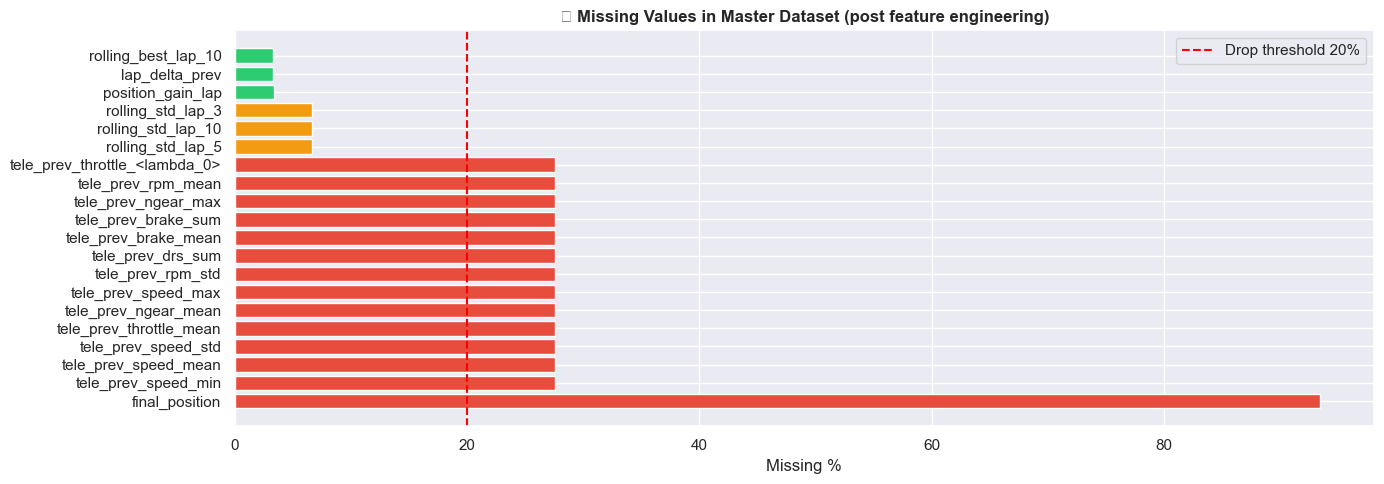

In [11]:
# Feature validation: show missing % after engineering
miss = (master.isnull().mean()*100).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if v>20 else '#f39c12' if v>5 else '#2ecc71' for v in miss.values]
ax.barh(miss.index, miss.values, color=colors)
ax.axvline(20, color='red', ls='--', label='Drop threshold 20%')
ax.set_xlabel('Missing %')
ax.set_title('📊 Missing Values in Master Dataset (post feature engineering)', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()


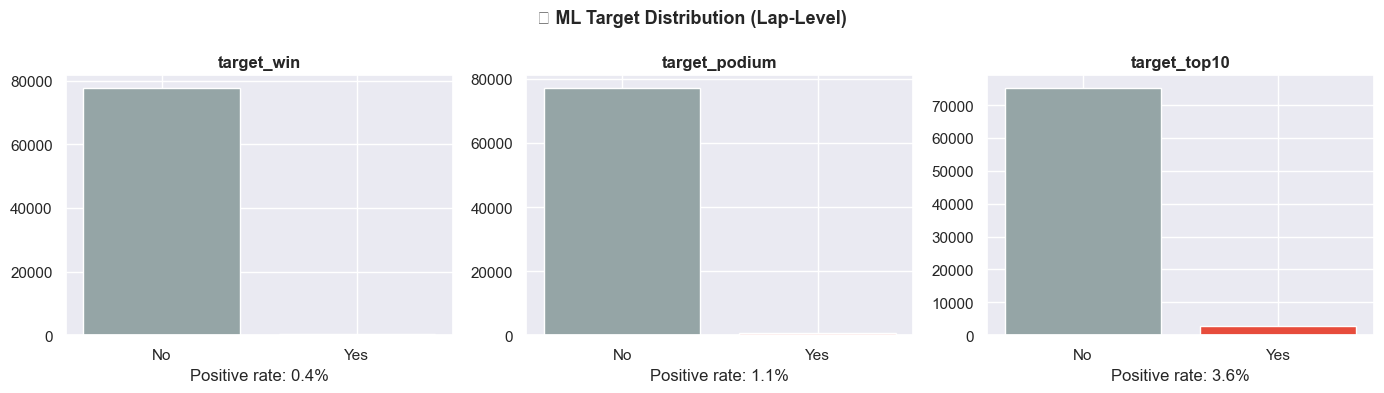

In [12]:
# Target distribution
if 'target_win' in master.columns:
    targets = ['target_win','target_podium','target_top10']
    targets = [t for t in targets if t in master.columns]
    fig, axes = plt.subplots(1, len(targets), figsize=(14, 4))
    if len(targets)==1: axes=[axes]
    for ax, t in zip(axes, targets):
        vals = master[t].dropna().astype(int).value_counts().sort_index()
        ax.bar(vals.index, vals.values, color=['#95a5a6','#e74c3c'], edgecolor='white')
        ax.set_xticks([0,1]); ax.set_xticklabels(['No','Yes'])
        ax.set_title(t, fontweight='bold')
        rate = vals.get(1,0)/vals.sum()
        ax.set_xlabel(f'Positive rate: {rate:.1%}')
    plt.suptitle('🎯 ML Target Distribution (Lap-Level)', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


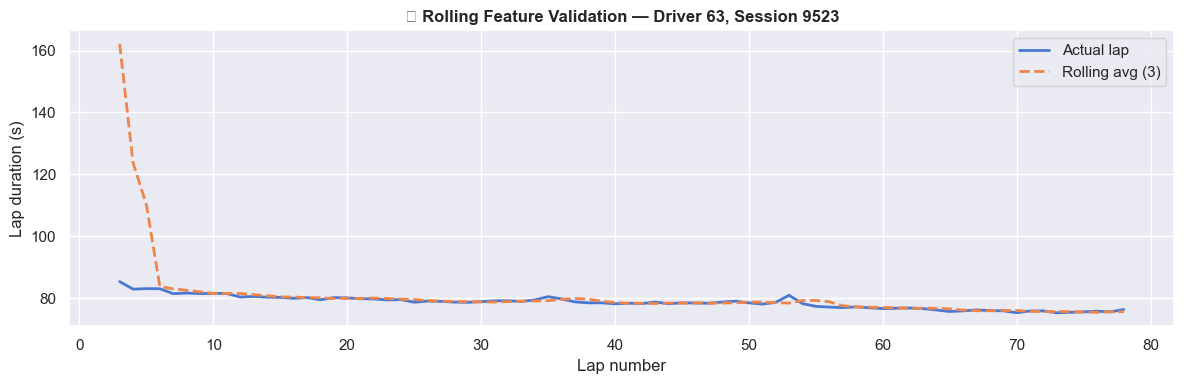

✅ Rolling avg is smoother than actual — no future leak (shift(1) applied)


In [13]:
# Rolling feature sanity check: plot avg lap_3 vs lap_duration for 1 driver
if 'rolling_avg_lap_3' in master.columns:
    sample = master.dropna(subset=['lap_duration','rolling_avg_lap_3'])
    if not sample.empty:
        drv = sample['driver_number'].value_counts().index[0]
        sk  = sample[sample['driver_number']==drv]['session_key'].value_counts().index[0]
        drv_df = sample[(sample['driver_number']==drv)&(sample['session_key']==sk)].sort_values('lap_number')
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(drv_df['lap_number'], drv_df['lap_duration'], label='Actual lap', lw=2)
        ax.plot(drv_df['lap_number'], drv_df['rolling_avg_lap_3'], label='Rolling avg (3)', lw=2, ls='--')
        ax.set_xlabel('Lap number'); ax.set_ylabel('Lap duration (s)')
        ax.set_title(f'📈 Rolling Feature Validation — Driver {drv}, Session {sk}', fontweight='bold')
        ax.legend(); plt.tight_layout(); plt.show()
        print('✅ Rolling avg is smoother than actual — no future leak (shift(1) applied)')


---
## ✅ Summary
| Feature Group | Count | Tình trạng |
|---|---|---|
| Rolling window (3/5/10 laps) | 9 cols | ✅ |
| Tyre features (age, cliff, compound) | 5 cols | ✅ |
| Weather (temp, humidity, evolution) | 5+ cols | ✅ |
| Position features | 4 cols | ✅ |
| Race progress (completion%, laps_to_go) | 2 cols | ✅ |
| ML targets | 3 cols | ✅ |

**Next step:** Feature Selection (VIF + Spearman) → Encoding → Train/Test Split → Modeling


In [15]:
if 'target_win' in master.columns:
    print(f'Master dataset ready for modeling:')
    print(f'  Shape: {master.shape}')
    print(f'  Win rate: {master["target_win"].mean():.3%}')
    print(f'  Saved to: data/processed/master_dataset.csv')
    print(f'  Columns: {list(master.columns)}')


Master dataset ready for modeling:
  Shape: (78023, 73)
  Win rate: 0.356%
  Saved to: data/processed/master_dataset.csv
  Columns: ['session_key', 'driver_number', 'lap_number', 'meeting_key', 'date_start', 'duration_sector_1', 'duration_sector_2', 'duration_sector_3', 'i1_speed', 'i2_speed', 'is_pit_out_lap', 'lap_duration', 'segments_sector_1', 'segments_sector_2', 'segments_sector_3', 'st_speed', 'is_outlier_lap', 'year', 'session_type', 'circuit_key', 'circuit_short_name', 'country_name', 'date_start_sess', 'date_end', 'full_name', 'name_acronym', 'team_name', 'compound', 'stint_number', 'current_tyre_age', 'compound_cliff', 'laps_until_cliff', 'is_past_cliff', 'rolling_avg_lap_3', 'rolling_std_lap_3', 'rolling_best_lap_3', 'rolling_avg_lap_5', 'rolling_std_lap_5', 'rolling_best_lap_5', 'rolling_avg_lap_10', 'rolling_std_lap_10', 'rolling_best_lap_10', 'lap_delta_prev', 'laps_to_go', 'race_completion_pct', 'air_temperature', 'track_temperature', 'humidity', 'rainfall', 'wind_speed

In [14]:
# Tyre cliff summary table
from src.feature_engineering import learn_tyre_cliffs, _read
from pathlib import Path
cliffs = learn_tyre_cliffs(stints, laps)
cliff_df = pd.DataFrame([{'Compound':k,'Cliff Lap':v,'Meaning':f'After lap {v} in stint → performance drops'} for k,v in cliffs.items()])
print('=== Learned Tyre Cliff Points ===')
display(cliff_df.style.set_caption('Hybrid: 60% data-learned + 40% domain knowledge'))


2026-05-25 09:59:55,189 | INFO | src.feature_engineering |   Tyre cliff [MEDIUM]: learned=26 domain=33 → blended=28
2026-05-25 09:59:55,202 | INFO | src.feature_engineering |   Tyre cliff [SOFT]: learned=2 domain=22 → blended=10
2026-05-25 09:59:55,228 | INFO | src.feature_engineering |   Tyre cliff [INTERMEDIATE]: learned=22 domain=20 → blended=21
2026-05-25 09:59:55,239 | INFO | src.feature_engineering |   Tyre cliff [WET]: learned=2 domain=15 → blended=7
2026-05-25 09:59:55,250 | INFO | src.feature_engineering |   Tyre cliff [UNKNOWN]: learned=10 domain=30 → blended=18


=== Learned Tyre Cliff Points ===


,Compound,Cliff Lap,Meaning
0,SOFT,10,After lap 10 in stint → performance drops
1,MEDIUM,28,After lap 28 in stint → performance drops
2,HARD,45,After lap 45 in stint → performance drops
3,INTERMEDIATE,21,After lap 21 in stint → performance drops
4,WET,7,After lap 7 in stint → performance drops
5,UNKNOWN,18,After lap 18 in stint → performance drops
